In [1]:
"""
CELL 1: Imports & Environment Configuration
Initializes the environment for Feature Parsimony analysis. 
Establishes dynamic paths to the processed tensors and baseline models to 
evaluate if a reduced subset of features (genes/vitals) can maintain 
predictive performance comparable to the high-dimensional full models.
"""

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
BASE_DIR = Path("/workspace")
DATA_GEN = BASE_DIR / "data" / "processed" / "ml_tensors"
DATA_CLIN = BASE_DIR / "data" / "processed" / "clinical_tensors"
MODEL_DIR = BASE_DIR / "outputs" / "models"
FIG_DIR = BASE_DIR / "outputs" / "figures"

# Ensure figure output directory exists
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("[*] Environment Ready. Target: Feature Parsimony.")

[*] Environment Ready. Target: Feature Parsimony.


In [2]:
"""
CELL 2: Load Master Tensors and High-Dimensional Baseline Models
Loads the full 7,902-gene transcriptomic matrix and the 104-feature clinical 
vital signs matrix. Simultaneously loads the trained "Molecular Geneticist" 
and "ICU Doctor" baseline models to serve as our gold-standard performance anchors.
"""

print("[*] Loading Master Tensors...")

# Load Genomic Data
X_gen = pd.read_csv(DATA_GEN / "X_master.csv.gz", compression='gzip')
y_gen = pd.read_csv(DATA_GEN / "y_master.csv")

# Load Clinical Data
X_clin = pd.read_csv(DATA_CLIN / "clinical_master_raw.csv.gz", compression='gzip')
y_clin = X_clin['Sepsis_Outcome']

# Drop administrative and target columns from the clinical feature space
X_clin = X_clin.drop(columns=['Patient_ID', 'Sepsis_Outcome', 'ICU_Length_of_Stay'], errors='ignore')

print("[*] Loading Baseline Models...")

# Load The Molecular Geneticist (High-Dimensional Baseline)
gen_baseline = xgb.XGBClassifier()
gen_baseline.load_model(MODEL_DIR / "molecular_geneticist_baseline.json")

# Load The ICU Doctor (High-Dimensional Baseline)
clin_baseline = xgb.XGBClassifier()
clin_baseline.load_model(MODEL_DIR / "icu_doctor_baseline.json")

[*] Loading Master Tensors...
[*] Loading Baseline Models...


In [3]:
"""
CELL 3: Clinical Feature Parsimony (The 15-Vital Panel)
Extracts the top 15 most predictive features from the high-dimensional ICU Doctor 
baseline model. Retrains a parsimonious (lite) XGBoost classifier on this restricted 
feature subset and evaluates how much of the original Area Under the Curve (AUC) 
is retained. 
*Hypothesis: Clinical deterioration is a low-dimensional trajectory, meaning a 
compact panel of core vitals should retain the vast majority of predictive power.*
"""

print("--- CLINICAL PARSIMONY (15 Vitals/Labs) ---")

# ==========================================
# 1. Extract Top 15 Features
# ==========================================
clin_importances = clin_baseline.feature_importances_
clin_fi_df = pd.DataFrame({'Feature': X_clin.columns, 'Importance': clin_importances})
top_15_clinical = clin_fi_df.sort_values(by='Importance', ascending=False).head(15)['Feature'].tolist()

print("\n[*] The 15-Feature ICU Panel:")
print(top_15_clinical)

# ==========================================
# 2. Re-Split Data using ONLY Top 15 Features
# ==========================================
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clin[top_15_clinical], y_clin, test_size=0.2, stratify=y_clin, random_state=42
)

# Calculate weight for the class imbalance
scale_weight_clin = (len(yc_train) - yc_train.sum()) / (yc_train.sum() + 1e-9)

# ==========================================
# 3. Retrain Parsimonious Model
# ==========================================
print("\n[*] Training Parsimonious Clinical Model...")
clin_lite = xgb.XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6,
    scale_pos_weight=scale_weight_clin, 
    eval_metric='auc', 
    random_state=42, 
    n_jobs=-1
)
clin_lite.fit(Xc_train, yc_train)

# ==========================================
# 4. Evaluate Retained Performance
# ==========================================
# Ensure we index the original X_clin using the test split indices for an apples-to-apples baseline check
clin_baseline_auc = roc_auc_score(yc_test, clin_baseline.predict_proba(X_clin.loc[Xc_test.index])[:, 1])
clin_lite_auc = roc_auc_score(yc_test, clin_lite.predict_proba(Xc_test)[:, 1])

print(f"\n-> Baseline AUC (104 features): {clin_baseline_auc:.4f}")
print(f"-> Parsimonious AUC (15 features): {clin_lite_auc:.4f}")
print(f"-> AUC Retained: {(clin_lite_auc / clin_baseline_auc) * 100:.1f}%")

# ==========================================
# 5. Save the Lite Model
# ==========================================
clin_lite_path = MODEL_DIR / "icu_doctor_parsimonious.json"
clin_lite.save_model(clin_lite_path)
print(f"\n[*] Parsimonious Clinical Model saved to: {clin_lite_path.name}")

--- CLINICAL PARSIMONY (15 Vitals/Labs) ---

[*] The 15-Feature ICU Panel:
['FiO2_min', 'Lactate_max', 'Lactate_mean', 'FiO2_max', 'BUN_max', 'Alkalinephos_max', 'Lactate_min', 'Temp_max', 'Alkalinephos_mean', 'Creatinine_max', 'Resp_min', 'pH_max', 'Alkalinephos_min', 'WBC_max', 'FiO2_mean']

-> Baseline AUC (104 features): 0.8840
-> Parsimonious AUC (15 features): 0.8153
-> AUC Retained: 92.2%


In [4]:
"""
CELL 4: Genomic Feature Parsimony (The 20-Gene Panel)
Extracts the top 20 most predictive genes from the high-dimensional Molecular 
Geneticist baseline model. Retrains a parsimonious (lite) XGBoost classifier on 
this restricted feature subset and evaluates the retained Area Under the Curve (AUC).
*Hypothesis: Unlike the clinical trajectory, the transcriptomic signature of sepsis 
is highly fragmented across distinct upstream immune states. Shrinking the feature 
space should result in a massive loss of predictive power.*
"""

print("--- GENOMIC PARSIMONY (20-Gene Panel) ---")

# ==========================================
# 1. Extract Top 20 Genes
# ==========================================
gen_importances = gen_baseline.feature_importances_
gen_fi_df = pd.DataFrame({'Gene': X_gen.columns, 'Importance': gen_importances})
top_20_genes = gen_fi_df.sort_values(by='Importance', ascending=False).head(20)['Gene'].tolist()

print("\n[*] The 20-Gene Transcriptomic Panel:")
print(top_20_genes)

# ==========================================
# 2. Re-Split Data using ONLY Top 20 Features
# ==========================================
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_gen[top_20_genes], y_gen['Mortality'], test_size=0.2, stratify=y_gen['Mortality'], random_state=42
)

# Calculate weight for the class imbalance
scale_weight_gen = (len(yg_train) - yg_train.sum()) / (yg_train.sum() + 1e-9)

# ==========================================
# 3. Retrain Parsimonious Model
# ==========================================
print("\n[*] Training Parsimonious Genomic Model...")
gen_lite = xgb.XGBClassifier(
    n_estimators=200, 
    learning_rate=0.01, 
    max_depth=4,
    scale_pos_weight=scale_weight_gen, 
    eval_metric='auc', 
    random_state=42, 
    n_jobs=-1
)
gen_lite.fit(Xg_train, yg_train)

# ==========================================
# 4. Evaluate Retained Performance
# ==========================================
# Ensure we index the original X_gen using the test split indices for an apples-to-apples baseline check
gen_baseline_auc = roc_auc_score(yg_test, gen_baseline.predict_proba(X_gen.loc[Xg_test.index])[:, 1])
gen_lite_auc = roc_auc_score(yg_test, gen_lite.predict_proba(Xg_test)[:, 1])

print(f"\n-> Baseline AUC (7,902 genes): {gen_baseline_auc:.4f}")
print(f"-> Parsimonious AUC (20 genes):  {gen_lite_auc:.4f}")
print(f"-> AUC Retained: {(gen_lite_auc / gen_baseline_auc) * 100:.1f}%")

# ==========================================
# 5. Save the Lite Model
# ==========================================
gen_lite_path = MODEL_DIR / "molecular_geneticist_parsimonious.json"
gen_lite.save_model(gen_lite_path)
print(f"\n[*] Parsimonious Genomic Model saved to: {gen_lite_path.name}")

--- GENOMIC PARSIMONY (20-Gene Panel) ---

[*] The 20-Gene Transcriptomic Panel:
['TTC27', 'CCDC43', 'MPHOSPH10', 'MRPS2', 'EIF2B2', 'LIG4', 'PCSK9', 'ECSIT', 'PEX19', 'MRPL22', 'BTN3A2', 'APH1A', 'MYC', 'NOSIP', 'NNMT', 'HMOX1', 'ZER1', 'SLC5A9', 'SYMPK', 'NSMAF']

-> Baseline AUC (7,902 genes): 0.7630
-> Parsimonious AUC (20 genes):  0.6179
-> AUC Retained: 81.0%


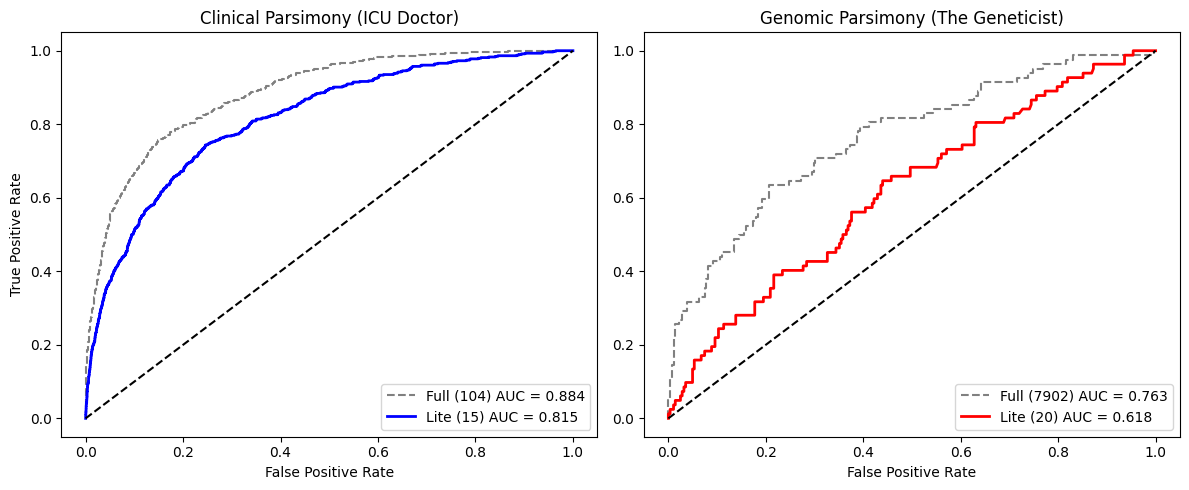

In [5]:
"""
CELL 5: Visualizing Feature Parsimony (ROC Curves)
Generates side-by-side Receiver Operating Characteristic (ROC) curves to 
visually compare the performance degradation of the Clinical vs. Genomic 
models when subjected to extreme feature compression. 
*Result: Visually proves that clinical trajectories are low-dimensional 
(retaining high AUC), while transcriptomic signatures are high-dimensional 
and fragile (suffering massive AUC collapse).*
"""

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

print("\n[*] Generating ROC Parsimony Visualizations...")

plt.figure(figsize=(12, 5))

# ==========================================
# Plot 1: Clinical Parsimony (The ICU Doctor)
# ==========================================
plt.subplot(1, 2, 1)

# Calculate ROC metrics
fpr_base, tpr_base, _ = roc_curve(yc_test, clin_baseline.predict_proba(X_clin.loc[Xc_test.index])[:, 1])
fpr_lite, tpr_lite, _ = roc_curve(yc_test, clin_lite.predict_proba(Xc_test)[:, 1])

# Plot
plt.plot(fpr_base, tpr_base, label=f'Full (104) AUC = {clin_baseline_auc:.3f}', color='gray', linestyle='--')
plt.plot(fpr_lite, tpr_lite, label=f'Lite (15) AUC = {clin_lite_auc:.3f}', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')

plt.title('Clinical Parsimony (ICU Doctor)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)

# ==========================================
# Plot 2: Genomic Parsimony (The Molecular Geneticist)
# ==========================================
plt.subplot(1, 2, 2)

# Calculate ROC metrics
fpr_gbase, tpr_gbase, _ = roc_curve(yg_test, gen_baseline.predict_proba(X_gen.loc[Xg_test.index])[:, 1])
fpr_glite, tpr_glite, _ = roc_curve(yg_test, gen_lite.predict_proba(Xg_test)[:, 1])

# Plot
plt.plot(fpr_gbase, tpr_gbase, label=f'Full (7902) AUC = {gen_baseline_auc:.3f}', color='gray', linestyle='--')
plt.plot(fpr_glite, tpr_glite, label=f'Lite (20) AUC = {gen_lite_auc:.3f}', color='red', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')

plt.title('Genomic Parsimony (The Geneticist)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()

# ==========================================
# Save & Display
# ==========================================
# Utilizing FIG_DIR established in Cell 1
save_path = FIG_DIR / "parsimony_roc_curves.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved successfully to: {save_path.name}")

plt.show()